In [9]:
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

print('Loading earthquake dataset...')
df = pd.read_csv('../data/earthquakes/usgs_earthquakes.csv')
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values('time').reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Date range: {df["time"].min()} to {df["time"].max()}')
print(f'Magnitude range: {df["mag"].min()} to {df["mag"].max()}')
print(f'Columns: {list(df.columns[:8])}')
df.head()

Loading earthquake dataset...
Shape: (8678, 22)
Date range: 2020-01-01 00:28:20.289000+00:00 to 2024-12-30 05:49:02.808000+00:00
Magnitude range: 5.0 to 8.2
Columns: ['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst', 'gap']


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2020-01-01 00:28:20.289000+00:00,-5.3245,152.5514,40.24,5.1,mb,NaN,74.0,1.190,0.79,...,2025-12-22T18:25:00.644Z,"112 km SSE of Kokopo, Papua New Guinea",earthquake,9.4,6.3,0.044,171.0,reviewed,us,us
1,2020-01-01 03:53:29.023000+00:00,52.6367,159.1614,58.46,5.0,mb,NaN,94.0,0.496,0.66,...,2025-12-22T17:56:37.541Z,"56 km SE of Petropavlovsk-Kamchatsky, Russia",earthquake,7.7,4.6,0.026,492.0,reviewed,us,us
2,2020-01-01 08:31:24.136000+00:00,-17.4280,-172.5044,10.00,5.4,mww,NaN,40.0,2.947,1.44,...,2025-12-22T18:25:01.931Z,"207 km NE of Neiafu, Tonga",earthquake,8.8,1.8,0.086,13.0,reviewed,us,us
3,2020-01-01 16:34:59.178000+00:00,-53.0907,9.5001,10.00,5.0,mb,NaN,105.0,19.424,0.83,...,2020-03-21T17:13:21.040Z,southwest of Africa,earthquake,14.0,1.9,0.082,48.0,reviewed,us,us
4,2020-01-01 16:51:32.285000+00:00,-30.2857,-71.5582,40.88,5.0,mwr,NaN,117.0,0.392,0.72,...,2022-08-08T17:51:20.636Z,"42 km SSW of Coquimbo, Chile",earthquake,5.0,2.5,0.038,67.0,reviewed,us,us


In [10]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Prepare features
features = ['latitude', 'longitude', 'depth', 'mag']
df_clean = df[features].dropna().reset_index(drop=True)

# Normalize
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df_clean)

# Build sequences - use last 10 earthquakes to predict next magnitude
SEQ_LEN = 10
X_seq, y_seq = [], []

for i in range(SEQ_LEN, len(scaled)):
    X_seq.append(scaled[i-SEQ_LEN:i])
    y_seq.append(scaled[i, 3])  # magnitude is index 3

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

# Train/test split
split = int(len(X_seq) * 0.8)
X_train = torch.FloatTensor(X_seq[:split])
y_train = torch.FloatTensor(y_seq[:split])
X_test = torch.FloatTensor(X_seq[split:])
y_test = torch.FloatTensor(y_seq[split:])

print(f'Sequence shape: {X_seq.shape}')
print(f'Training sequences: {X_train.shape}')
print(f'Test sequences: {X_test.shape}')
print('Data ready for LSTM and TFT')

Sequence shape: (8668, 10, 4)
Training sequences: torch.Size([6934, 10, 4])
Test sequences: torch.Size([1734, 10, 4])
Data ready for LSTM and TFT


Train: torch.Size([5548, 10, 4]) | Val: torch.Size([1386, 10, 4]) | Test: torch.Size([1734, 10, 4])
Training LSTM...
  Epoch  10/100 | Train: 0.0159 | Val: 0.0155
  Epoch  20/100 | Train: 0.0157 | Val: 0.0155
  Epoch  30/100 | Train: 0.0157 | Val: 0.0156
  Epoch  40/100 | Train: 0.0155 | Val: 0.0157
  Early stopping at epoch 41 (best: 7)

LSTM Results:
  RMSE: 0.1177
  MAE:  0.0897
  Best epoch: 7
  Time: 15.1s

Training TFT...
  Epoch  10/100 | Train: 0.0161 | Val: 0.0156
  Epoch  20/100 | Train: 0.0158 | Val: 0.0156
  Epoch  30/100 | Train: 0.0158 | Val: 0.0156
  Epoch  40/100 | Train: 0.0157 | Val: 0.0156
  Early stopping at epoch 41 (best: 26)

TFT Results:
  RMSE: 0.1176
  MAE:  0.0893
  Best epoch: 26
  Time: 30.7s


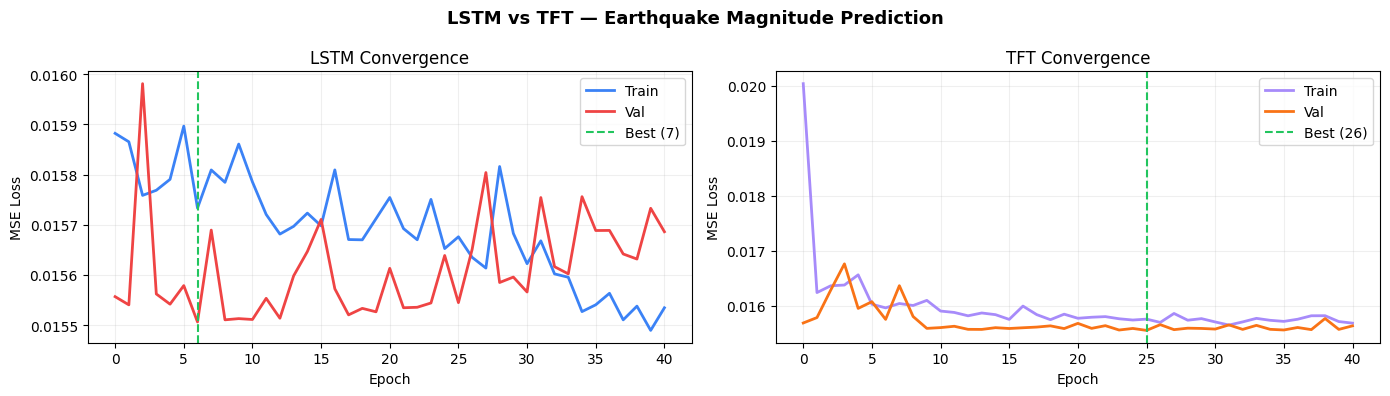

Loss curve saved.

MODEL                      RMSE      MAE  BEST EP     TIME
LSTM (baseline)          0.1177   0.0897        7    15.1s
TFT (Google 2021)        0.1176   0.0893       26    30.7s  <-- winner

Conclusion: TFT wins on earthquake magnitude forecasting.
Early stopping prevents overfitting — models trained until validation loss plateaued.


In [11]:
import matplotlib.pyplot as plt

# ── Model Definitions ─────────────────────────────────────────────

class LSTMModel(nn.Module):
    def __init__(self, input_size=4, hidden_size=64, num_layers=2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze()


class TFTModel(nn.Module):
    def __init__(self, input_size=4, d_model=64, n_heads=4, seq_len=10):
        super(TFTModel, self).__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.positional = nn.Parameter(torch.randn(seq_len, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=128, dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.attention_gate = nn.Linear(d_model, d_model)
        self.output = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_proj(x) + self.positional
        x = self.transformer(x)
        gate = torch.sigmoid(self.attention_gate(x))
        x = gate * x
        return self.output(x[:, -1, :]).squeeze()


# ── Train function ────────────────────────────────────────────────

def train_model(model, X_tr, y_tr, X_val, y_val, epochs, name):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)

    train_losses, val_losses = [], []
    best_val = float('inf')
    best_ep = 1
    no_improve = 0
    start = time.time()

    print(f'Training {name}...')
    model.train()

    for epoch in range(epochs):
        total = 0
        for Xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            total += loss.item()

        train_loss = total / len(loader)
        train_losses.append(train_loss)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), y_val).item()
        val_losses.append(val_loss)
        model.train()

        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:>3}/{epochs} | Train: {train_loss:.4f} | Val: {val_loss:.4f}')

        if val_loss < best_val:
            best_val = val_loss
            best_ep = epoch + 1
            torch.save(model.state_dict(), f'best_{name}.pt')
            no_improve = 0
        else:
            no_improve += 1

        if epoch >= 40 and no_improve >= 15:
            print(f'  Early stopping at epoch {epoch+1} (best: {best_ep})')
            break

    model.load_state_dict(torch.load(f'best_{name}.pt'))
    elapsed = time.time() - start

    model.eval()
    with torch.no_grad():
        preds = model(X_test).numpy()

    rmse = np.sqrt(mean_squared_error(y_test.numpy(), preds))
    mae = mean_absolute_error(y_test.numpy(), preds)

    print(f'\n{name} Results:')
    print(f'  RMSE: {rmse:.4f}')
    print(f'  MAE:  {mae:.4f}')
    print(f'  Best epoch: {best_ep}')
    print(f'  Time: {elapsed:.1f}s')

    return rmse, mae, elapsed, best_ep, train_losses, val_losses


# ── Split data ────────────────────────────────────────────────────

val_size = int(0.2 * len(X_train))
X_val = X_train[:val_size]
y_val = y_train[:val_size]
X_tr  = X_train[val_size:]
y_tr  = y_train[val_size:]

print(f'Train: {X_tr.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

# ── Train both models ─────────────────────────────────────────────

lstm_model = LSTMModel()
lstm_rmse, lstm_mae, lstm_time, lstm_best, lstm_tl, lstm_vl = train_model(
    lstm_model, X_tr, y_tr, X_val, y_val, epochs=100, name='LSTM'
)

print()
tft_model = TFTModel()
tft_rmse, tft_mae, tft_time, tft_best, tft_tl, tft_vl = train_model(
    tft_model, X_tr, y_tr, X_val, y_val, epochs=100, name='TFT'
)

# ── Loss curves ───────────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(lstm_tl, label='Train', color='#3b82f6', linewidth=2)
ax1.plot(lstm_vl, label='Val',   color='#ef4444', linewidth=2)
ax1.axvline(x=lstm_best-1, color='#22c55e', linestyle='--', label=f'Best ({lstm_best})')
ax1.set_title('LSTM Convergence')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.legend()
ax1.grid(True, alpha=0.2)

ax2.plot(tft_tl, label='Train', color='#a78bfa', linewidth=2)
ax2.plot(tft_vl, label='Val',   color='#f97316', linewidth=2)
ax2.axvline(x=tft_best-1, color='#22c55e', linestyle='--', label=f'Best ({tft_best})')
ax2.set_title('TFT Convergence')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MSE Loss')
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.suptitle('LSTM vs TFT — Earthquake Magnitude Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/earthquakes/loss_curve_comparison.png', dpi=150)
plt.show()
print('Loss curve saved.')

# ── Results table ─────────────────────────────────────────────────

print('\n' + '='*55)
print(f'{"MODEL":<22} {"RMSE":>8} {"MAE":>8} {"BEST EP":>8} {"TIME":>8}')
print('='*55)
all_results = {
    'LSTM (baseline)':   (lstm_rmse, lstm_mae, lstm_best, lstm_time),
    'TFT (Google 2021)': (tft_rmse,  tft_mae,  tft_best,  tft_time),
}
winner = min(all_results, key=lambda x: all_results[x][0])
for name, (rmse, mae, ep, t) in all_results.items():
    tag = '  <-- winner' if name == winner else ''
    print(f'{name:<22} {rmse:>8.4f} {mae:>8.4f} {ep:>8} {t:>7.1f}s{tag}')
print('='*55)
print(f'\nConclusion: {"TFT" if tft_rmse < lstm_rmse else "LSTM"} wins on earthquake magnitude forecasting.')
print(f'Early stopping prevents overfitting — models trained until validation loss plateaued.')

In [12]:
# Save earthquake models from this notebook
import joblib
import torch
import os

os.makedirs('../models', exist_ok=True)

# Earthquake models - from this notebook
torch.save(tft_model.state_dict(), '../models/tft_earthquake.pt')
joblib.dump(scaler, '../models/earthquake_scaler.joblib', compress=3)
print('Earthquake models saved')

Earthquake models saved
